   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  


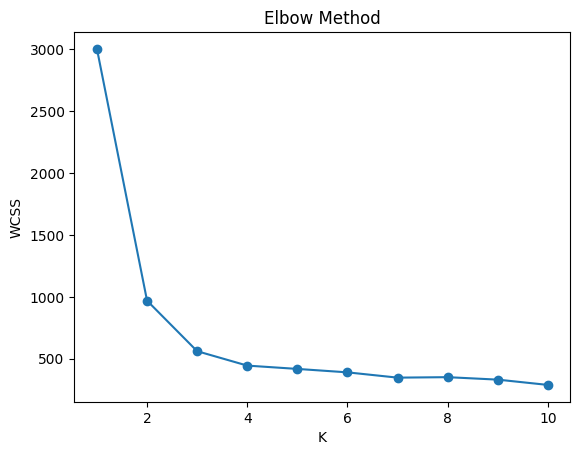

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster  
0                         6        2  
1                         3        0  
2                         4        2  
3                         2        0  
4                         1        0  

Centroids:
           0         1         2         3         4         5
0 -1.094595 -1.036122  1.114284 -0.934278 -0.813494 -1.045346
1  1.132214  1.235574 -1.106680  1.253260  1.125725  1.172991
2 -0.004449 -0.168055 -0.041370 -0.290670 -0.287579 -0.095968
Explained Variance: [0.83560354 0.05

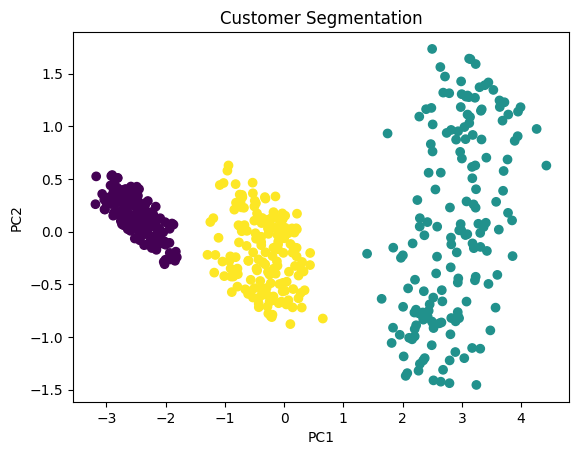

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Load Data
df = pd.read_csv('/Users/umeshkapil/Downloads/q2_customers.csv')

print(df.head())

# 2. Scaling
scaler = StandardScaler()
X = scaler.fit_transform(df)

# 3. Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

# 4. KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

print(df.head())

# 5. Centroids
centroids = pd.DataFrame(kmeans.cluster_centers_)
print("\nCentroids:\n", centroids)

# 6. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained Variance:", pca.explained_variance_ratio_)

# 7. Plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.title("Customer Segmentation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()